# Fake Job Posting Detection

## Business Problem

Online job portals contain both legitimate and fraudulent job postings. Fake job advertisements can lead to financial fraud, identity theft, and wasted time for job seekers.

The objective of this project is to build an NLP-based machine learning system that classifies whether a job posting is **Fraudulent** or **Legitimate** using only the textual information contained in the posting.

---

## Project Objectives

- Perform exploratory data analysis (EDA)
- Analyze text features
- Design an effective text preprocessing pipeline
- Compare multiple machine learning models
- Handle class imbalance appropriately
- Select the best production-ready model
- Prepare the model for deployment in an end-to-end ML system

---

## Why Text-Only?

The original dataset contains structured categorical features such as industry, employment type, and location.

For deployment, we intentionally use only textual information:

- Title
- Company Profile
- Description
- Requirements
- Benefits

These fields are merged into a single text input, allowing users to simply paste a job posting into the deployed application without requiring structured metadata.

## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import os
import joblib

import nltk
import unicodedata
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk import pos_tag

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder





In [2]:
df=pd.read_csv("../data/fake_job_postings.csv")
print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [4]:
df.describe(include='all').T    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,17880.0,NaN,NaN,NaN,8940.5,5161.655742,1.0,4470.75,8940.5,13410.25,17880.0
title,17880,11231,English Teacher Abroad,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,17534,3105,"GB, LND, London",718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,6333,1337,Sales,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_range,2868,874,0-0,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_profile,14572,1709,We help teachers get safe &amp; secure jobs ab...,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,17879,14801,"Play with kids, get paid for it Love travel? J...",379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requirements,15184,11967,University degree required. TEFL / TESOL / CEL...,410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,10668,6204,See job description,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telecommuting,17880.0,NaN,NaN,NaN,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0


In [5]:
df.dtypes

job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

### Key Observations

- Dataset contains structured and unstructured features.
- The target column is fraudulent.
- Majority of predictive information is expected to come from text.

## Missing Value Analysis

In [7]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

missing = (
    df[text_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="Missing Values")
)

missing

,Missing Values
benefits,7212
company_profile,3308
requirements,2696
description,1
title,0


In [8]:
missing_percent = (df[text_columns].isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing["Missing Values"],
    "Percentage": missing_percent
})

missing_df.sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
benefits,7212,40.335570
company_profile,3308,18.501119
requirements,2696,15.078300
description,1,0.005593
title,0,0.000000


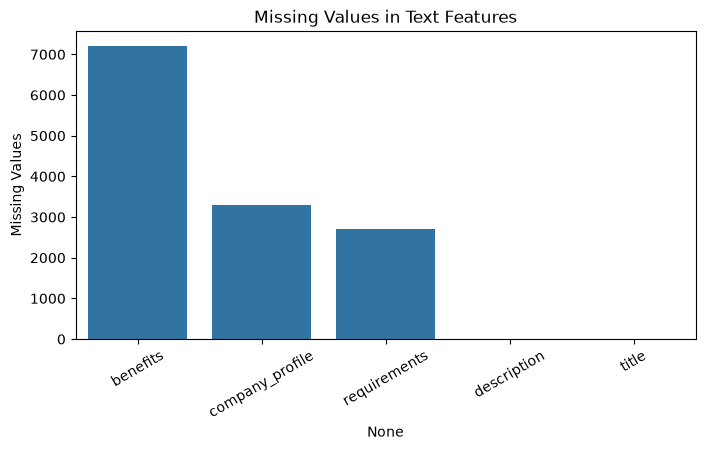

In [9]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=missing.index,
    y=missing["Missing Values"]
)
plt.xticks(rotation=30)
plt.title("Missing Values in Text Features")
plt.show()

### Key Observations

- Text columns contain missing values.
- Missing text values will be replaced with empty strings before merging.
- No rows will be dropped since each text field contributes useful information.

## Target Variable Analysis

In [10]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

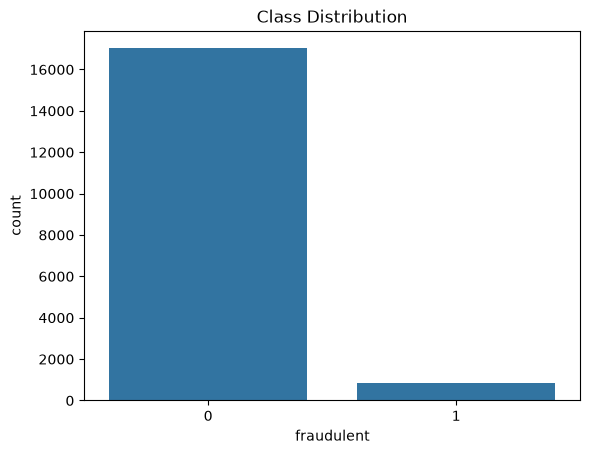

In [11]:
sns.countplot(
    data=df,
    x="fraudulent"
)

plt.title("Class Distribution")
plt.show()

In [12]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

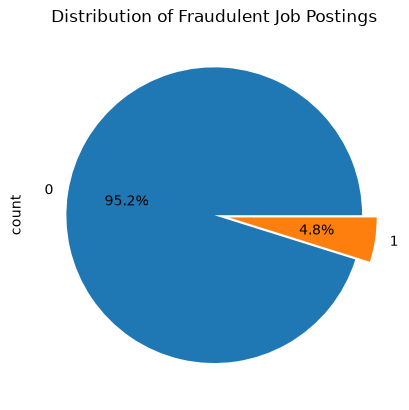

In [13]:
df['fraudulent'].value_counts().plot(kind='pie',autopct='%1.1f%%',explode=[0,0.1])
plt.title('Distribution of Fraudulent Job Postings')
plt.show()

### Key Observations

- The dataset is highly imbalanced.
- Fraudulent postings account for only about 5% of the data.
- Accuracy is not an appropriate evaluation metric.
- Precision, Recall, F1-score, and ROC-AUC will be prioritized.

## Text Feature Analysis

In [14]:
for col in text_columns:
    print("="*50)
    print(col)

    print("Missing :", df[col].isna().sum())

    print("Average Characters :",
          df[col].fillna("").str.len().mean())

    print("Average Words :",
          df[col].fillna("").str.split().str.len().mean())

title
Missing : 0
Average Characters : 28.530313199105144
Average Words : 3.7619127516778526
company_profile
Missing : 3308
Average Characters : 620.9014541387024
Average Words : 92.55357941834451
description
Missing : 1
Average Characters : 1218.004418344519
Average Words : 170.4459731543624
requirements
Missing : 2696
Average Characters : 590.1322147651007
Average Words : 78.0329418344519
benefits
Missing : 7212
Average Characters : 208.89569351230426
Average Words : 29.990883668903802


In [15]:
summary = pd.DataFrame({
    "Missing": [
        df[c].isna().sum()
        for c in text_columns
    ],
    "Avg Characters": [
        df[c].fillna("").str.len().mean()
        for c in text_columns
    ],
    "Avg Words": [
        df[c].fillna("").str.split().str.len().mean()
        for c in text_columns
    ]
}, index=text_columns)

summary

,Missing,Avg Characters,Avg Words
title,0,28.530313,3.761913
company_profile,3308,620.901454,92.553579
description,1,1218.004418,170.445973
requirements,2696,590.132215,78.032942
benefits,7212,208.895694,29.990884


In [16]:
df[text_columns].head()

,title,company_profile,description,requirements,benefits
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered


### Key Observations

- Description contains the richest textual information.
- Company Profile and Requirements also provide substantial context.
- Title is short but likely contains useful keywords.
- Benefits has the highest proportion of missing values.

## Merge Text Columns

In [17]:
df[text_columns] = df[text_columns].fillna("")

df["text"] = df[text_columns].agg(" ".join, axis=1)

In [18]:
df["text"].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: text, dtype: object

In [19]:
print("Average Characters:",
      df["text"].str.len().mean())

print("Average Words:",
      df["text"].str.split().str.len().mean())

Average Characters: 2670.4640939597316
Average Words: 374.7852908277405


### Key Observations

- Multiple text fields have been merged into a single document.
- The merged text will serve as the input feature for all NLP models.
- Missing values were replaced with empty strings before merging.

# EDA Summary

## Key Findings

- Dataset contains approximately 5% fraudulent postings.
- Significant class imbalance exists.
- Majority of useful information is contained in textual columns.
- Benefits contains the highest number of missing values.
- Description is the richest source of textual information.
- The five text columns were merged into a single feature for downstream NLP tasks.

---

## Next Steps

The next notebook focuses on:

- Text preprocessing
- TF-IDF vectorization
- Model training
- Model comparison